In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

final_df_k = {}
k_values = [1, 10, 30]

for k in k_values:
    final_df_k[k] = pd.read_csv(f"../../data/07_portfolios_metadata/complete_metadata_{k}.csv")

## Sector

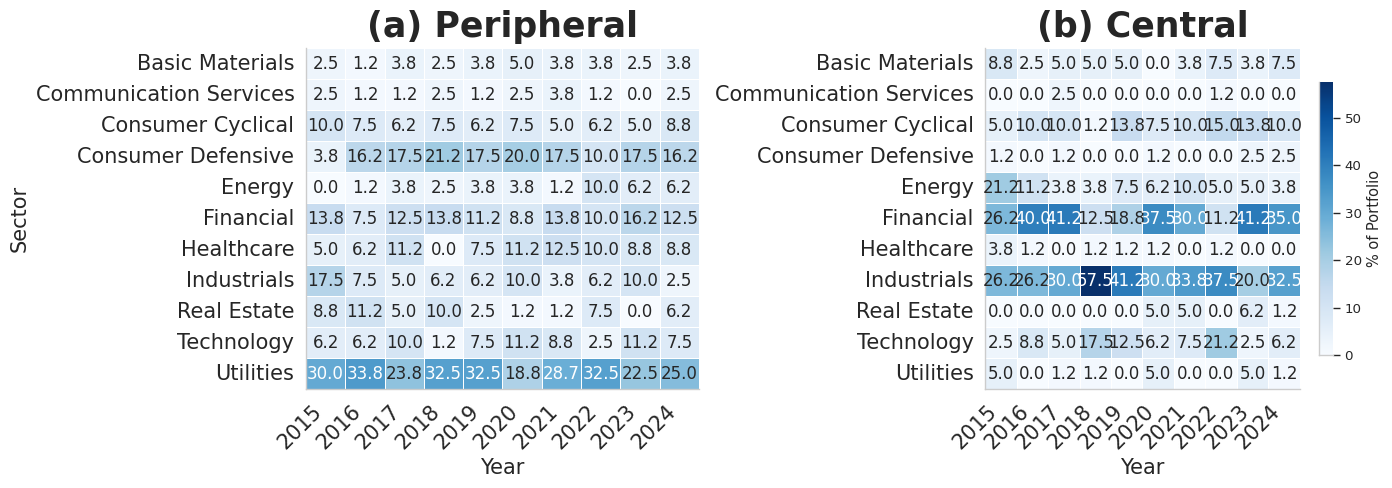

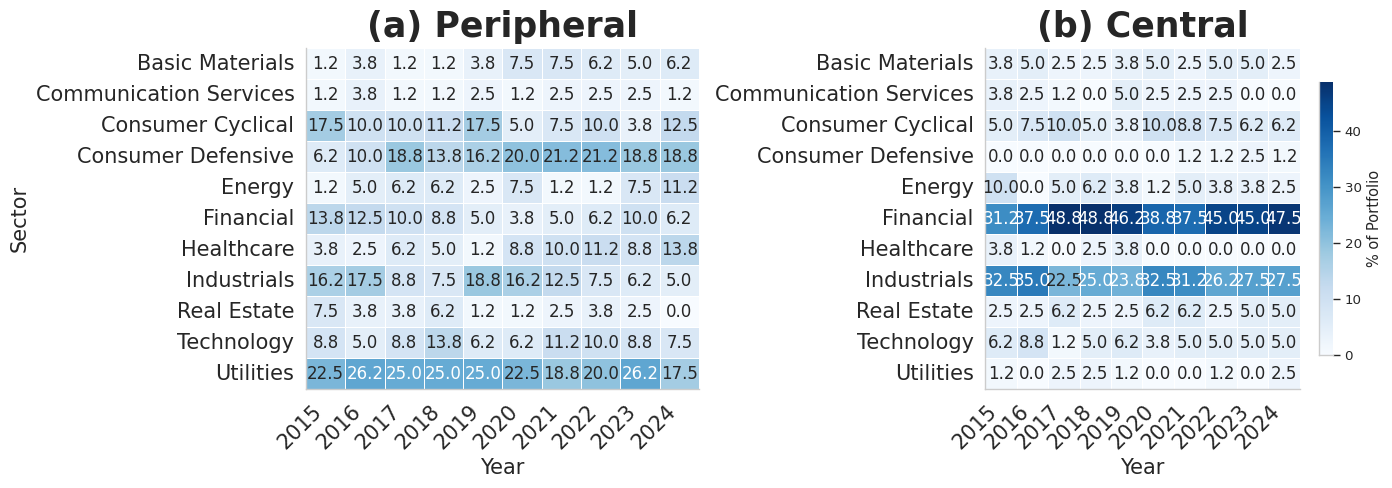

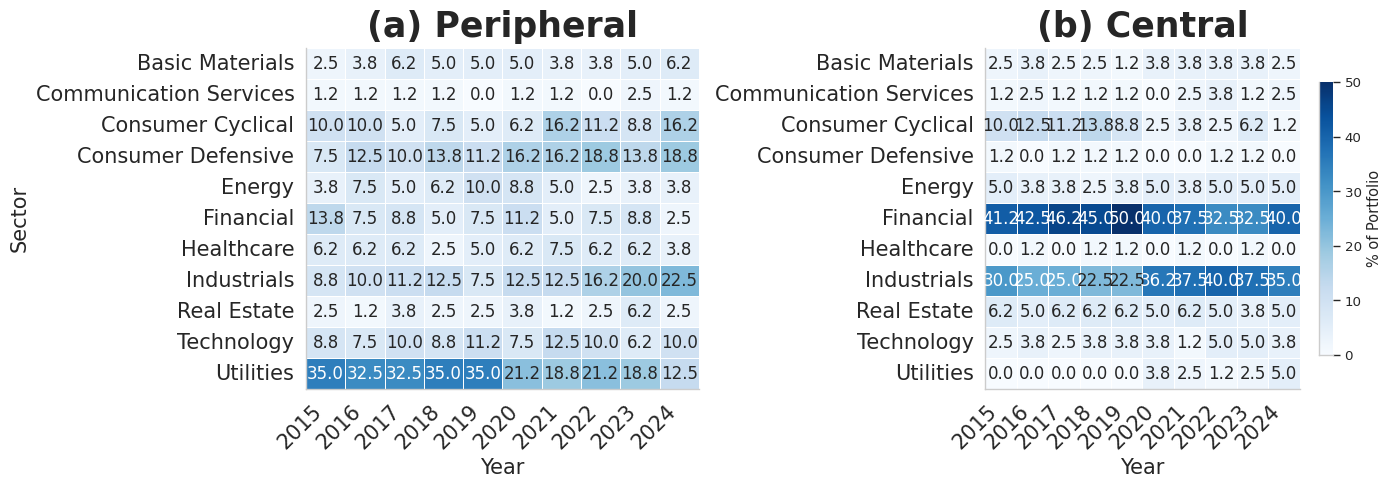

In [2]:
for k in k_values:
    final_df = final_df_k[k]
    
    sector_counts = (
        final_df
        .groupby(["portfolio", "year", "Sector"])
        .size()
        .reset_index(name="n_firms")
    )

    all_sectors = sorted(
        sector_counts["Sector"].unique().tolist()
    )

    # --- Compute sector % share per portfolio/year ---
    def pct_pivot(portfolio):
        piv = (
            sector_counts
            .query("portfolio == @portfolio")
            .pivot_table(index="Sector", columns="year", values="n_firms", fill_value=0)
            .reindex(index=all_sectors, fill_value=0)
        )
        # Normalize each year to 100%
        return piv.div(piv.sum(axis=0), axis=1) * 100

    central_pct    = pct_pivot("central")
    peripheral_pct = pct_pivot("peripheral")

    # --- Plot ---
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Shared color scale
    vmin, vmax = 0, max(central_pct.max().max(), peripheral_pct.max().max())

    for ax, df_pct, title, cbar in zip(
        axes,
        [peripheral_pct, central_pct],
        ["(a) Peripheral", "(b) Central"],
        [False, True],
    ):
        sns.heatmap(
            df_pct,
            ax=ax,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            vmin=vmin, vmax=vmax,
            linewidths=0.4,
            linecolor="white",
            cbar=cbar,
            cbar_kws={"label": "% of Portfolio", "shrink": 0.8} if cbar else {},
            annot_kws={"fontsize": 12},
        )
        ax.set_title(title, fontsize=25, fontweight="bold", pad=8)
        ax.set_xlabel("Year", fontsize=15)
        ax.set_ylabel("Sector" if ax == axes[0] else "", fontsize=15)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=15)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)

    # fig.suptitle("Sector Composition by Portfolio",
    #              fontsize=13, fontweight="bold", y=1.02)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.savefig(f"../../figures/window_{k}/sector_composition_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

## Boxplots

In [3]:
def plot_metric_boxplot_evolution(
    df,
    metric_prefix,
    portfolios=None,
    log_scale=False,
    figsize=(16, 5),
    showfliers=False,
    ylabel=None,
    title=None,
    save=False,
    out_dir="../../figures",
    dpi=300
):
    """
    Create publication-ready boxplots showing temporal evolution of a metric (metric_YYYY)
    in a grid, one panel per portfolio.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with Ticker, portfolio, and metric_YYYY columns
    metric_prefix : str
        Prefix of metric columns (e.g., 'Market_Cap', 'ROE')
    portfolios : list, optional
        List of portfolios to plot. If None, uses ['peripheral', 'central']
    log_scale : bool
        Whether to use log scale for y-axis
    figsize : tuple
        Figure size (width, height)
    showfliers : bool
        Whether to show outliers
    ylabel : str, optional
        Y-axis label (if None, uses metric_prefix)
    title : str, optional
        Overall figure title
    save : bool
        Whether to save the figure
    out_dir : str
        Output directory for saving
    dpi : int
        Resolution for saving
    """
    
    # Set publication-quality style
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)
    
    # Default portfolios (peripheral first)
    if portfolios is None:
        portfolios = ['peripheral', 'central']
    
    # Identify metric columns (metric_YYYY, exclude _cut)
    metric_cols = df.columns[
        df.columns.str.match(fr"^{metric_prefix}_\d{{4}}$")
    ].tolist()

    if len(metric_cols) == 0:
        raise ValueError(f"No columns found for '{metric_prefix}_YYYY'")

    # Reshape to long format
    metric_long = df.melt(
        id_vars=["Ticker", "portfolio"],
        value_vars=metric_cols,
        var_name="metric_year",
        value_name="value"
    )

    # Extract year
    metric_long["year"] = (
        metric_long["metric_year"]
        .str.replace(f"{metric_prefix}_", "", regex=False)
        .astype(int)
    )

    metric_long = metric_long.dropna(subset=["value"])
    
    # Professional color palette
    box_color = '#2E5C6E'
    median_color = "#22125F"
    
    # Font sizes
    TITLE_SIZE = 15
    LABEL_SIZE = 13
    TICK_SIZE = 11
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, portfolio in zip(axes, portfolios):
        data_p = metric_long[metric_long["portfolio"] == portfolio]
        
        # Get unique years and prepare data
        years = sorted(data_p["year"].unique())
        boxplot_data = [data_p[data_p["year"] == year]["value"].values for year in years]
        
        # Create boxplot
        bp = ax.boxplot(
            boxplot_data,
            labels=years,
            patch_artist=True,
            showfliers=showfliers,
            widths=0.6,
            medianprops=dict(color=median_color, linewidth=2.5),
            boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
            whiskerprops=dict(color='black', linewidth=1.2),
            capprops=dict(color='black', linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
        )

        # Set log scale if requested
        if log_scale:
            ax.set_yscale("log")
            y_label = f"{ylabel if ylabel else metric_prefix} (log scale)"
        else:
            y_label = ylabel if ylabel else metric_prefix

        # Styling
        ax.set_title(portfolio.capitalize(), fontsize=TITLE_SIZE, fontweight="bold", pad=15)
        ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        ax.set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
        
        # Clean up axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        
        # Grid
        ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
        ax.set_axisbelow(True)
        
        # Tick parameters
        ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, width=1.2)
        ax.tick_params(axis='x', rotation=45)

    # Add overall title if provided
    if title:
        fig.suptitle(title, fontsize=17, fontweight="bold", y=0.98)

    plt.tight_layout()
    
    # Save figure
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        
        # Save PNG
        filename = f"{metric_prefix}_evolution.png"
        fig.savefig(
            out_path / filename,
            dpi=dpi,
            bbox_inches="tight",
            facecolor='white',
            edgecolor='none'
        )

    plt.show()

In [4]:
def plot_metric_boxplot_evolution(
    metric_prefix,
    portfolios=None,
    log_scale=False,
    figsize=(10, 5),
    showfliers=False,
    ylabel=None,
    title=None,
    k=None,
    save=False,
    dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from pathlib import Path

    df = final_df_k[k]
    out_dir=f"../../figures/window_{k}"

    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)

    if portfolios is None:
        portfolios = ['peripheral', 'central']

    # --- Identify & reshape ---
    metric_cols = df.columns[
        df.columns.str.match(fr"^{metric_prefix}_\d{{4}}$")
    ].tolist()

    if len(metric_cols) == 0:
        raise ValueError(f"No columns found for '{metric_prefix}_YYYY'")

    metric_long = df.melt(
        id_vars=["Ticker", "portfolio"],
        value_vars=metric_cols,
        var_name="metric_year",
        value_name="value"
    )
    metric_long["year"] = (
        metric_long["metric_year"]
        .str.replace(f"{metric_prefix}_", "", regex=False)
        .astype(int)
    )
    metric_long = metric_long.dropna(subset=["value"])

    years = sorted(metric_long["year"].unique())
    n_years     = len(years)
    n_portfolios = len(portfolios)

    # --- Colors (colorblind-safe) ---
    palette = sns.color_palette("colorblind", n_colors=n_portfolios)
    median_colors = ["#1a1a2e", "#2e1a1a"]          # dark contrast per portfolio

    # --- Layout ---
    # Each year occupies a group; portfolios sit side-by-side within the group
    group_width  = 1.0                               # total width per year group
    box_width    = 0.30
    gap          = 0.05                              # gap between boxes in a group
    offsets      = np.linspace(
        -(n_portfolios - 1) * (box_width + gap) / 2,
         (n_portfolios - 1) * (box_width + gap) / 2,
        n_portfolios
    )

    TITLE_SIZE = 25
    LABEL_SIZE = 20
    TICK_SIZE  = 15

    fig, ax = plt.subplots(figsize=figsize)

    for p_idx, (portfolio, color, med_col) in enumerate(
        zip(portfolios, palette, median_colors)
    ):
        data_p = metric_long[metric_long["portfolio"] == portfolio]

        for y_idx, year in enumerate(years):
            values = data_p[data_p["year"] == year]["value"].dropna().values
            if len(values) == 0:
                continue

            x_pos = y_idx * group_width + offsets[p_idx]

            bp = ax.boxplot(
                values,
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops=dict(color=med_col,  linewidth=2.5),
                boxprops=dict(facecolor=color,   edgecolor="black",
                              linewidth=1.2,     alpha=0.75),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black",     linewidth=1.2),
                flierprops=dict(marker="o", markerfacecolor="gray",
                                markersize=4,    alpha=0.5),
            )

    # --- X-axis: one tick per year group ---
    ax.set_xticks([i * group_width for i in range(n_years)])
    ax.set_xticklabels(years, fontsize=TICK_SIZE, rotation=45)

    # --- Log scale ---
    if log_scale:
        ax.set_yscale("log")
        y_label = f"{ylabel if ylabel else metric_prefix} (log scale)"
    else:
        y_label = ylabel if ylabel else metric_prefix

    # --- Labels & spines ---
    ax.set_xlabel("Year",   fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)
    ax.set_ylabel(y_label,  fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE, width=1.2)

    # --- Single legend ---
    legend_patches = [
        mpatches.Patch(facecolor=color, edgecolor="black",
                       alpha=0.75, label=p.capitalize())
        for p, color in zip(portfolios, palette)
    ]
    ax.legend(
        handles=legend_patches,
        title="Portfolio",
        title_fontsize=15,
        fontsize=12,
        frameon=False,
    )

    if title:
        fig.suptitle(title, fontsize=17, fontweight="bold", y=1.01)

    plt.tight_layout(pad=0.1)

    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            out_path / f"{metric_prefix}_evolution.png",
            dpi=dpi, bbox_inches="tight",
            pad_inches=0.3,
            facecolor="white", edgecolor="none"
        )

    plt.show()

### Market Cap

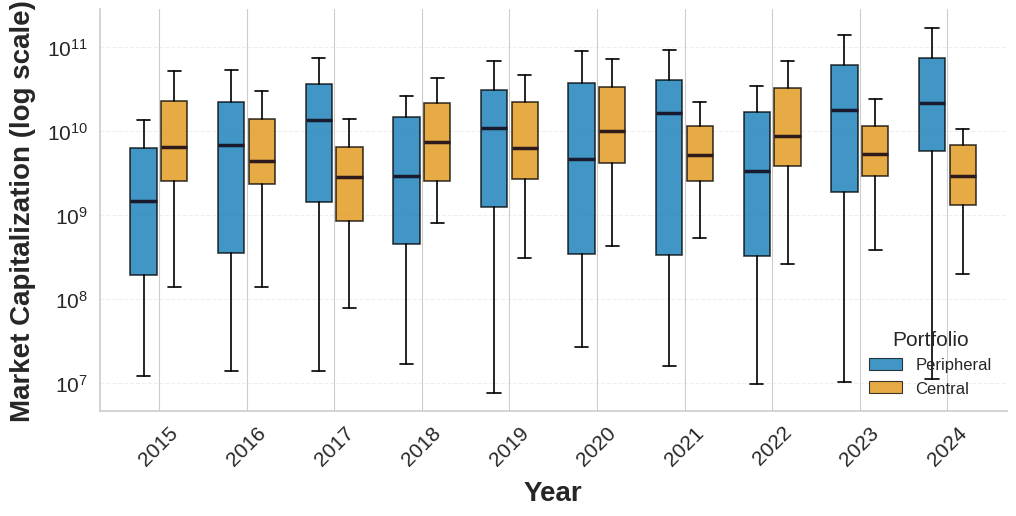

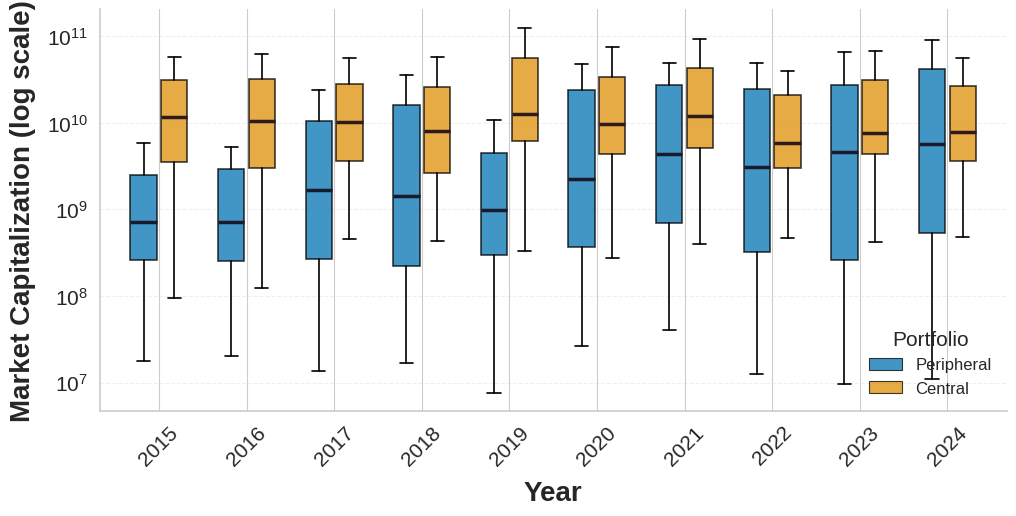

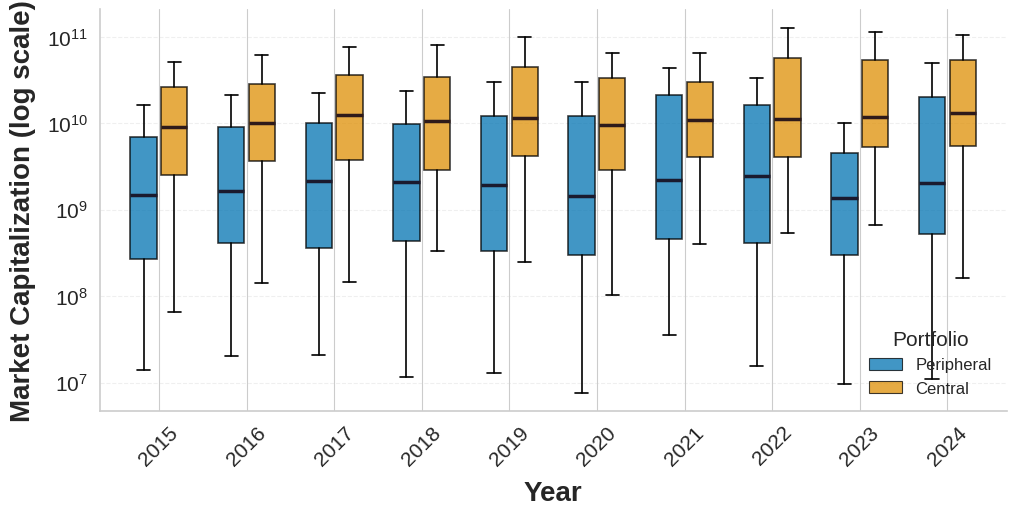

In [7]:
plot_metric_boxplot_evolution(
    k=1,
    metric_prefix="mcap",
    portfolios=None,
    log_scale=True,
    ylabel="Market Capitalization",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=10,
    metric_prefix="mcap",
    portfolios=None,
    log_scale=True,
    ylabel="Market Capitalization",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=30,
    metric_prefix="mcap",
    portfolios=None,
    log_scale=True,
    ylabel="Market Capitalization",
    title=None,
    save=True
)

### Beta

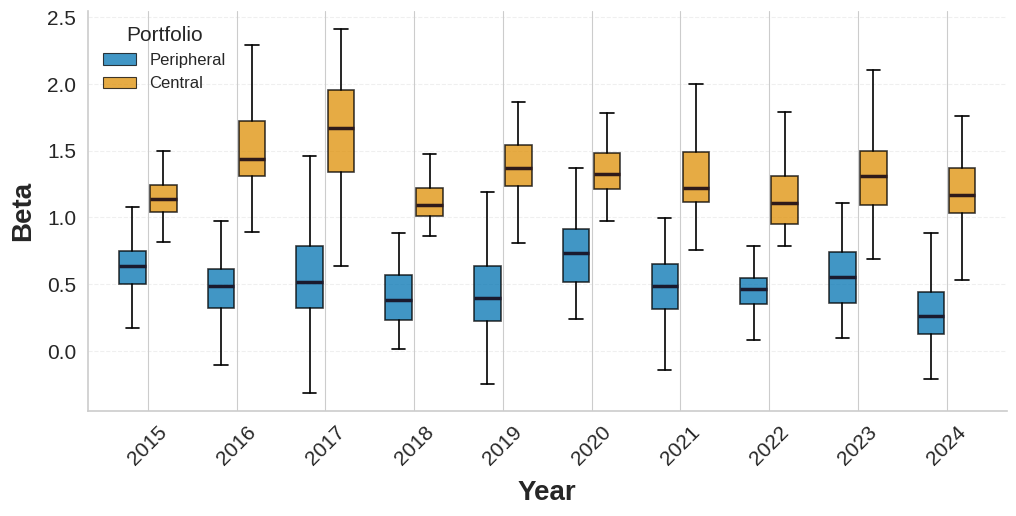

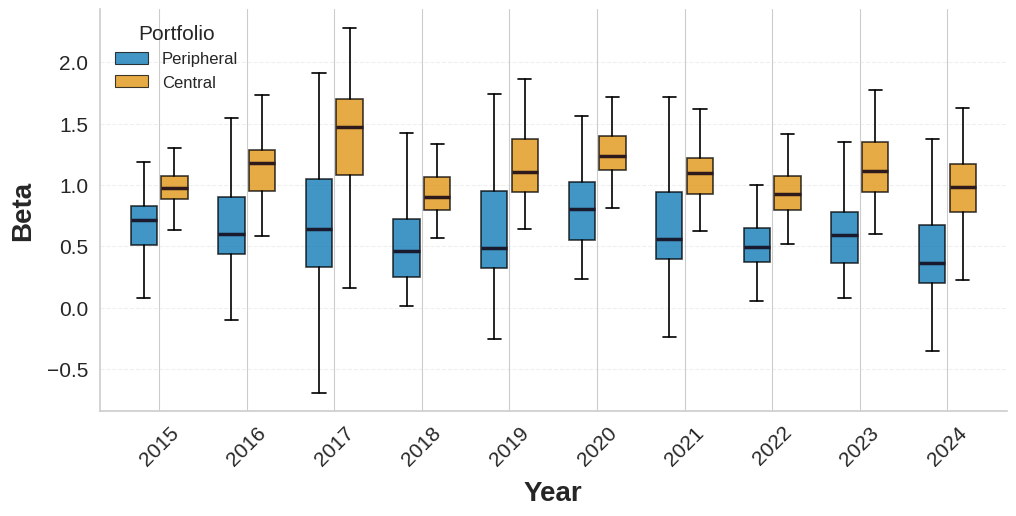

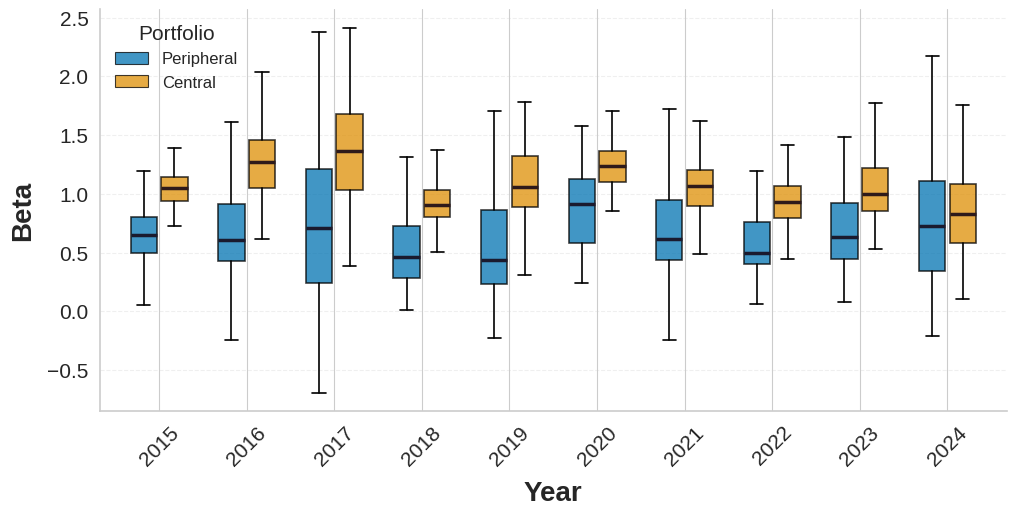

In [8]:
plot_metric_boxplot_evolution(
    k=1,
    metric_prefix="beta",
    portfolios=None,
    log_scale=False,
    ylabel="Beta",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=10,
    metric_prefix="beta",
    portfolios=None,
    log_scale=False,
    ylabel="Beta",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=30,
    metric_prefix="beta",
    portfolios=None,
    log_scale=False,
    ylabel="Beta",
    title=None,
    save=True
)

### Momentum

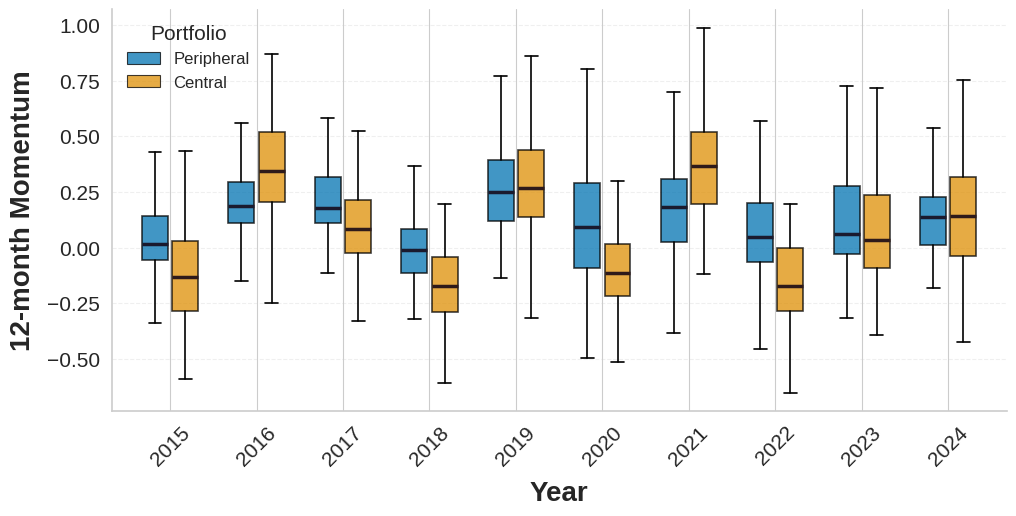

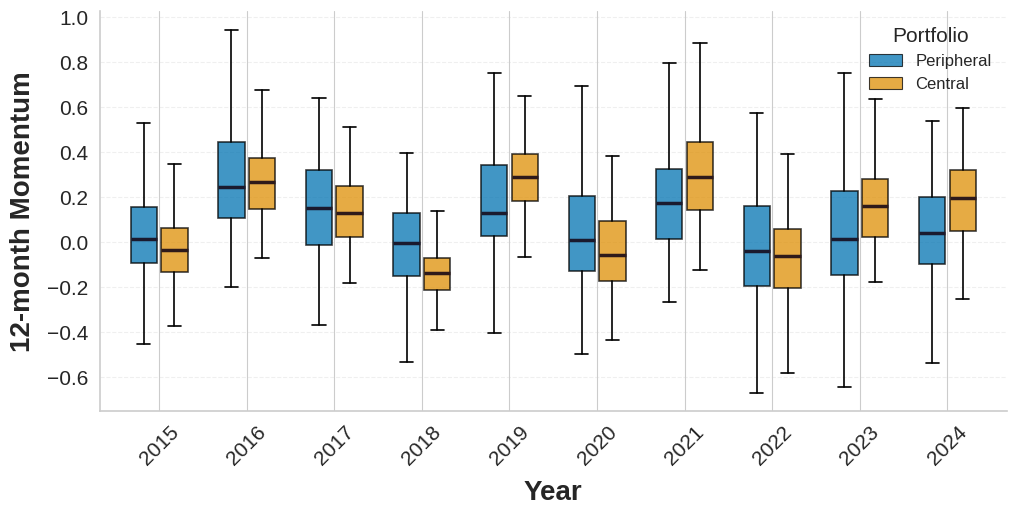

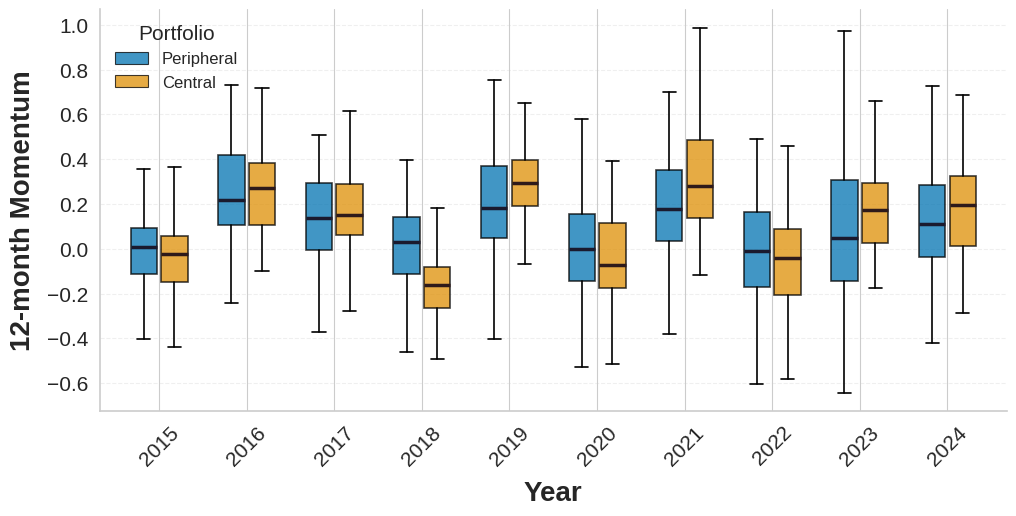

In [9]:
plot_metric_boxplot_evolution(
    k=1,
    metric_prefix="momentum",
    portfolios=None,
    log_scale=False,
    ylabel="12-month Momentum",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=10,
    metric_prefix="momentum",
    portfolios=None,
    log_scale=False,
    ylabel="12-month Momentum",
    title=None,
    save=True
)

plot_metric_boxplot_evolution(
    k=30,
    metric_prefix="momentum",
    portfolios=None,
    log_scale=False,
    ylabel="12-month Momentum",
    title=None,
    save=True
)

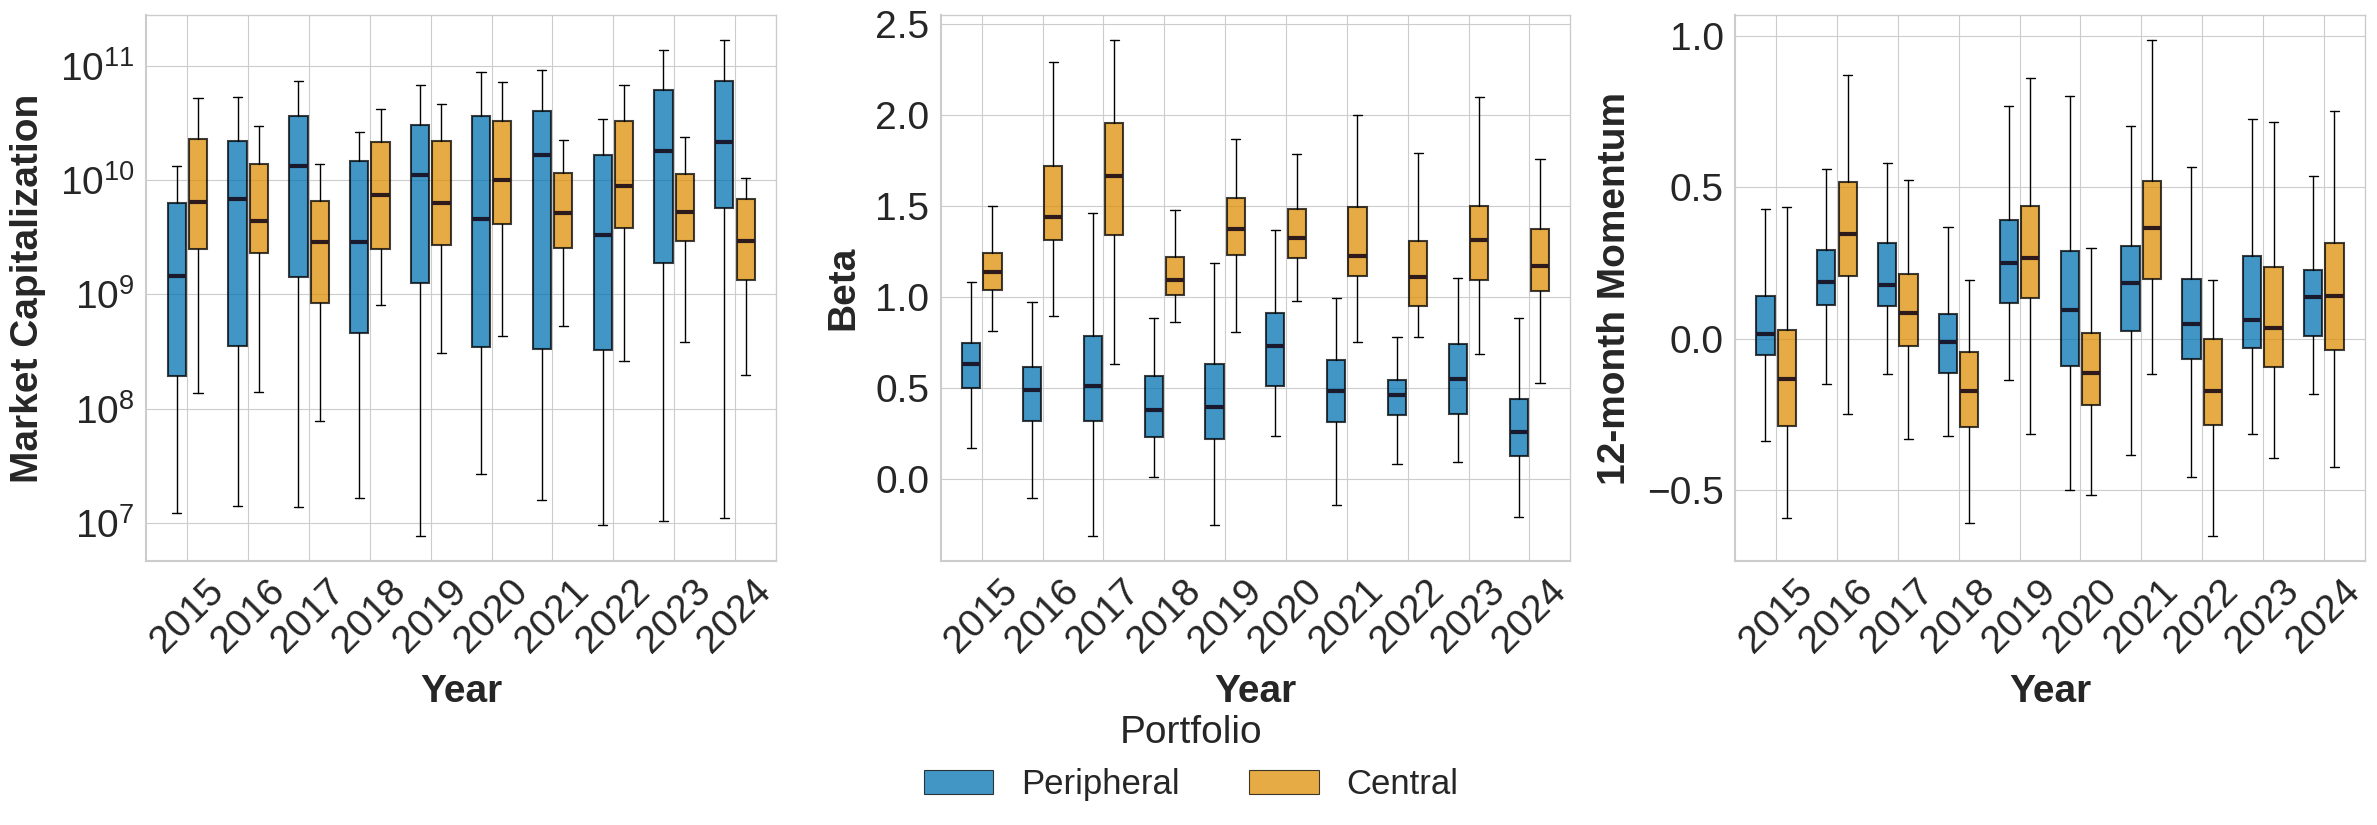

In [10]:
def plot_metric_boxplot_evolution_all(
    metric_prefix,
    portfolios=None,
    log_scale=False,
    figsize=(10, 5),
    showfliers=False,
    ylabel=None,
    title=None,
    k=None,
    save=False,
    dpi=300,
    ax=None,          # ← NEW: external axes to draw on
    add_legend=False
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from pathlib import Path

    df = final_df_k[k]
    out_dir = f"../../figures/window_{k}"

    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)

    if portfolios is None:
        portfolios = ['peripheral', 'central']

    # --- Identify & reshape ---
    metric_cols = df.columns[
        df.columns.str.match(fr"^{metric_prefix}_\d{{4}}$")
    ].tolist()

    if len(metric_cols) == 0:
        raise ValueError(f"No columns found for '{metric_prefix}_YYYY'")

    metric_long = df.melt(
        id_vars=["Ticker", "portfolio"],
        value_vars=metric_cols,
        var_name="metric_year",
        value_name="value"
    )
    metric_long["year"] = (
        metric_long["metric_year"]
        .str.replace(f"{metric_prefix}_", "", regex=False)
        .astype(int)
    )
    metric_long = metric_long.dropna(subset=["value"])

    years        = sorted(metric_long["year"].unique())
    n_years      = len(years)
    n_portfolios = len(portfolios)

    # --- Colors (colorblind-safe) ---
    palette       = sns.color_palette("colorblind", n_colors=n_portfolios)
    median_colors = ["#1a1a2e", "#2e1a1a"]

    # --- Layout ---
    group_width = 1.0
    box_width   = 0.30
    gap         = 0.05
    offsets     = np.linspace(
        -(n_portfolios - 1) * (box_width + gap) / 2,
         (n_portfolios - 1) * (box_width + gap) / 2,
        n_portfolios
    )

# --- UPDATED FONT SIZES FOR PAPER ---
    TITLE_SIZE = 32
    LABEL_SIZE = 28 # X and Y axis titles
    TICK_SIZE  = 28 # The numbers on the axes
    LEGEND_SIZE = 28

    # --- Create figure only when no external ax is supplied ---
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    for p_idx, (portfolio, color, med_col) in enumerate(zip(portfolios or ['peripheral', 'central'], palette, median_colors)):
        data_p = metric_long[metric_long["portfolio"] == portfolio]
        for y_idx, year in enumerate(years):
            values = data_p[data_p["year"] == year]["value"].dropna().values
            if len(values) == 0: continue
            x_pos = y_idx * group_width + offsets[p_idx]
            ax.boxplot(values, positions=[x_pos], widths=box_width, patch_artist=True, showfliers=showfliers,
                        medianprops=dict(color=med_col, linewidth=3), # Thicker median
                        boxprops=dict(facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.75))

    # --- Applying the larger fonts ---
    ax.set_xticks([i * group_width for i in range(n_years)])
    ax.set_xticklabels(years, fontsize=TICK_SIZE, rotation=45)

    if log_scale: ax.set_yscale("log")

    ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
    ax.set_ylabel(ylabel if ylabel else metric_prefix, fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

    # Ensure the tick numbers (the values) are large
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    # If log scale, make sure minor ticks are also legible or handled
    ax.tick_params(axis='y', which='minor', labelsize=TICK_SIZE-4)

    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    if add_legend:
        legend_patches = [
            mpatches.Patch(facecolor=color, edgecolor="black", alpha=0.75, label=p.capitalize())
            for p, color in zip(portfolios or ['peripheral', 'central'], palette)
        ]
        ax.legend(handles=legend_patches, title="Portfolio", title_fontsize=LEGEND_SIZE+2, fontsize=LEGEND_SIZE, frameon=False)

    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)

    # --- Only show/save when running standalone ---
    if standalone:
        plt.tight_layout()
        if save:
            out_path = Path(out_dir)
            out_path.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                out_path / f"{metric_prefix}_evolution.png",
                dpi=dpi, bbox_inches="tight",
                facecolor="white", edgecolor="none"
            )
        plt.show()


# ── Combined 3-panel figure ───────────────────────────────────────────────────
import matplotlib.patches as mpatches

k_val = 1 # Change to 10 for your second plot
panels = [
    dict(metric_prefix="mcap",     log_scale=True,  ylabel="Market Capitalization"),
    dict(metric_prefix="beta",     log_scale=False, ylabel="Beta"),
    dict(metric_prefix="momentum", log_scale=False, ylabel="12-month Momentum"),
]

# Increase figsize height slightly to accommodate the legend at the bottom
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 

for ax, kwargs in zip(axes, panels):
    # CRITICAL: Pass add_legend=False here
    plot_metric_boxplot_evolution_all(k=k_val, ax=ax, add_legend=False, portfolios=['peripheral', 'central'], **kwargs)

# Create a single legend for the entire figure
# We manually create the patches to match the colorblind palette used in the function
palette = sns.color_palette("colorblind", n_colors=2)
legend_patches = [
    mpatches.Patch(facecolor=palette[0], edgecolor="black", alpha=0.75, label="Peripheral"),
    mpatches.Patch(facecolor=palette[1], edgecolor="black", alpha=0.75, label="Central")
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Centers legend at bottom
    ncol=2,
    title="Portfolio",
    title_fontsize=28,
    fontsize=25,
    frameon=False
)

# Use rect to stop tight_layout from overlapping the legend we just positioned
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

# Save logic
out_path = Path(f"../../figures/window_{k_val}")
out_path.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path / "mcap_beta_momentum_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

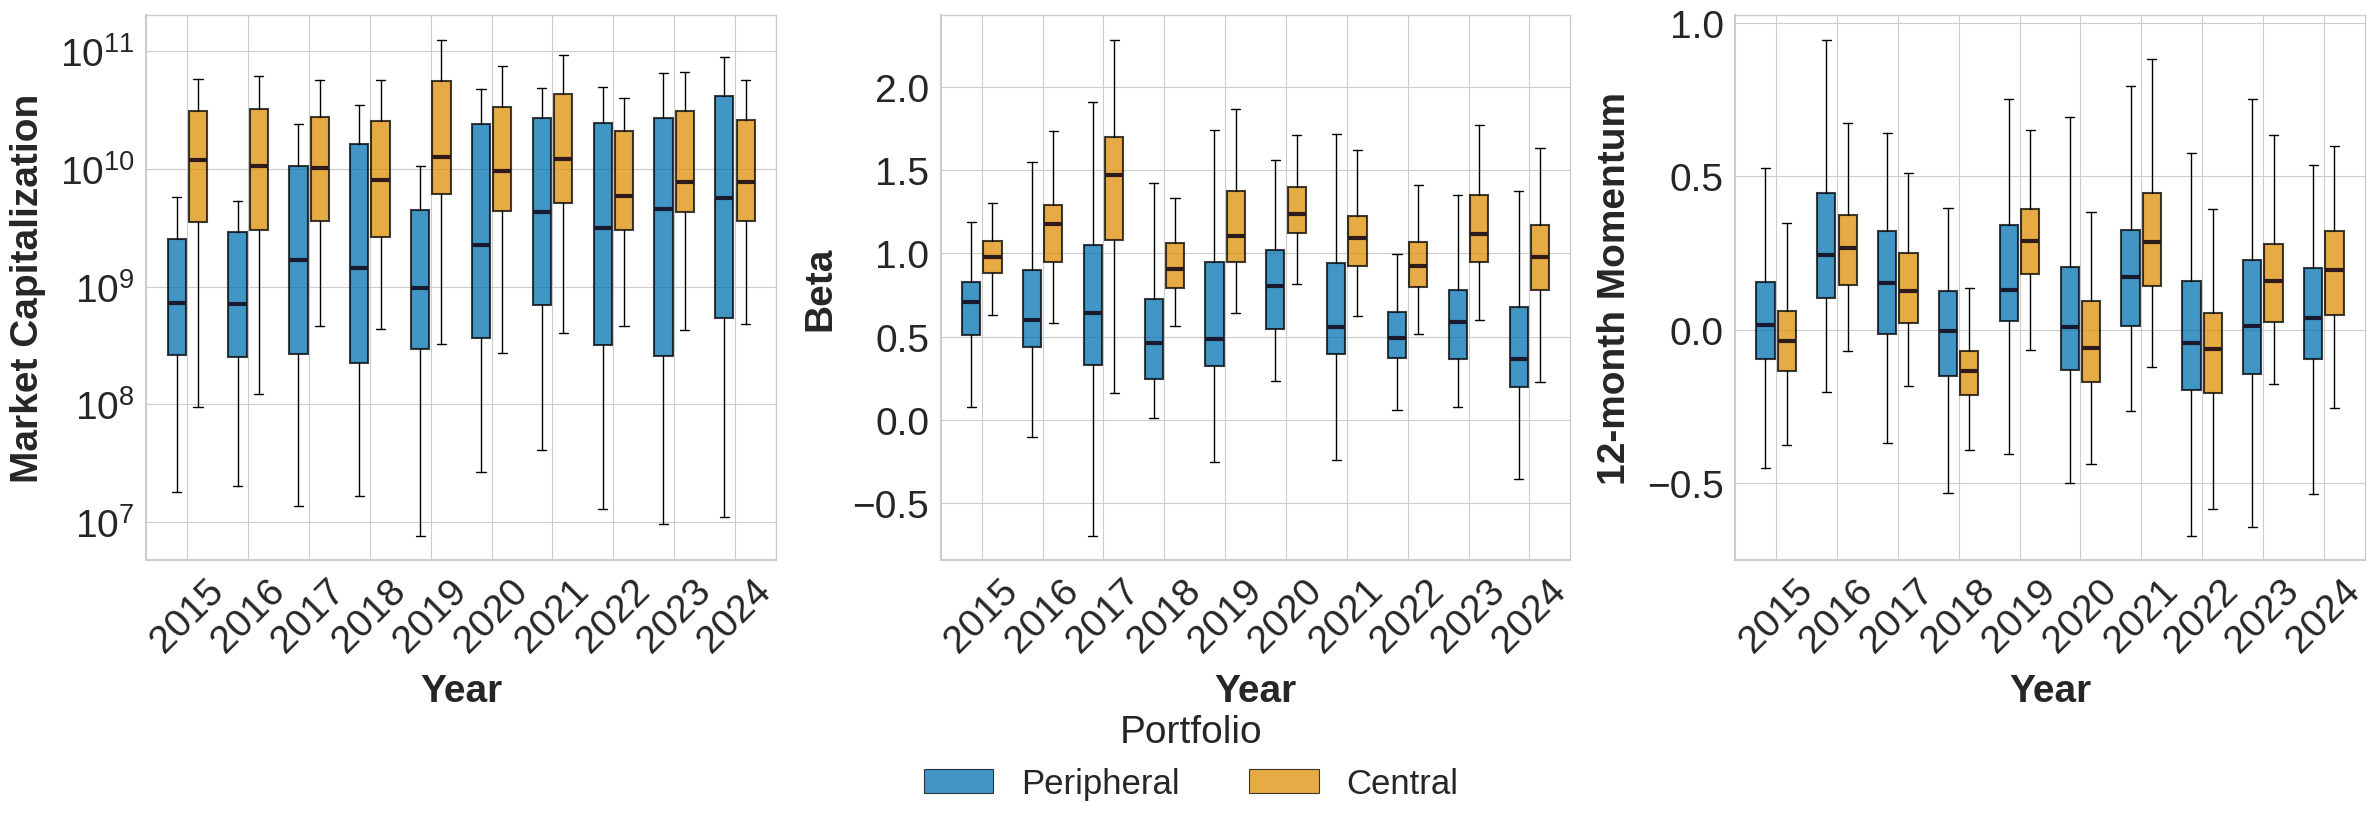

In [11]:
k_val = 10
panels = [
    dict(metric_prefix="mcap",     log_scale=True,  ylabel="Market Capitalization"),
    dict(metric_prefix="beta",     log_scale=False, ylabel="Beta"),
    dict(metric_prefix="momentum", log_scale=False, ylabel="12-month Momentum"),
]

# Increase figsize height slightly to accommodate the legend at the bottom
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 

for ax, kwargs in zip(axes, panels):
    # CRITICAL: Pass add_legend=False here
    plot_metric_boxplot_evolution_all(k=k_val, ax=ax, add_legend=False, portfolios=['peripheral', 'central'], **kwargs)

# Create a single legend for the entire figure
# We manually create the patches to match the colorblind palette used in the function
palette = sns.color_palette("colorblind", n_colors=2)
legend_patches = [
    mpatches.Patch(facecolor=palette[0], edgecolor="black", alpha=0.75, label="Peripheral"),
    mpatches.Patch(facecolor=palette[1], edgecolor="black", alpha=0.75, label="Central")
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Centers legend at bottom
    ncol=2,
    title="Portfolio",
    title_fontsize=28,
    fontsize=25,
    frameon=False
)

# Use rect to stop tight_layout from overlapping the legend we just positioned
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

# Save logic
out_path = Path(f"../../figures/window_{k_val}")
out_path.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path / "mcap_beta_momentum_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

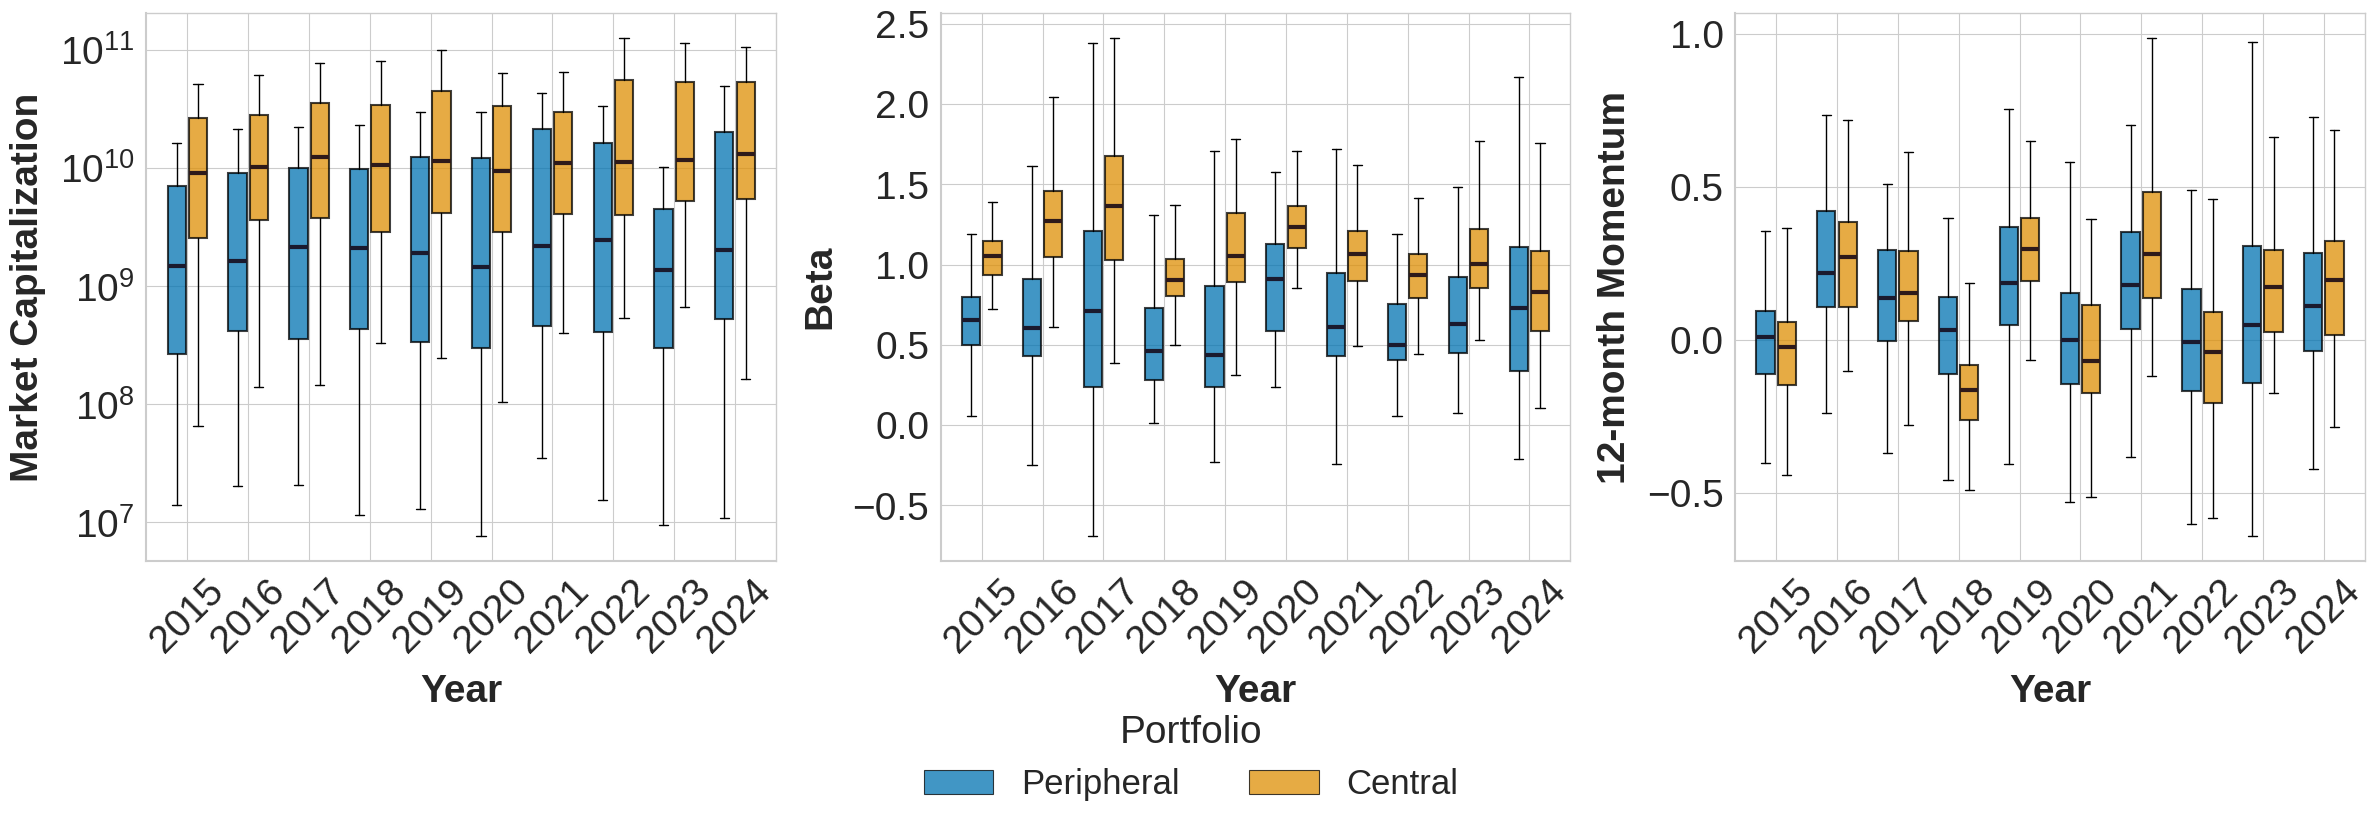

In [12]:
k_val = 30
panels = [
    dict(metric_prefix="mcap",     log_scale=True,  ylabel="Market Capitalization"),
    dict(metric_prefix="beta",     log_scale=False, ylabel="Beta"),
    dict(metric_prefix="momentum", log_scale=False, ylabel="12-month Momentum"),
]

# Increase figsize height slightly to accommodate the legend at the bottom
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 

for ax, kwargs in zip(axes, panels):
    # CRITICAL: Pass add_legend=False here
    plot_metric_boxplot_evolution_all(k=k_val, ax=ax, add_legend=False, portfolios=['peripheral', 'central'], **kwargs)

# Create a single legend for the entire figure
# We manually create the patches to match the colorblind palette used in the function
palette = sns.color_palette("colorblind", n_colors=2)
legend_patches = [
    mpatches.Patch(facecolor=palette[0], edgecolor="black", alpha=0.75, label="Peripheral"),
    mpatches.Patch(facecolor=palette[1], edgecolor="black", alpha=0.75, label="Central")
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Centers legend at bottom
    ncol=2,
    title="Portfolio",
    title_fontsize=28,
    fontsize=25,
    frameon=False
)

# Use rect to stop tight_layout from overlapping the legend we just positioned
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

# Save logic
out_path = Path(f"../../figures/window_{k_val}")
out_path.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path / "mcap_beta_momentum_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

## Composition

In [13]:
turnover_df_k = {}

for k in k_values:
    final_df = final_df_k[k]

    assets_by_py = (
        final_df
        .groupby(["portfolio", "year"])["Ticker"]
        .apply(set)
        .reset_index(name="assets")
    )

    assets_by_py = assets_by_py.sort_values(["portfolio", "year"])

    rows = []

    # Group by BOTH portfolio and n
    for (portfolio,), g in assets_by_py.groupby(["portfolio"]):
        g = g.sort_values("year").reset_index(drop=True)

        for i in range(1, len(g)):
            year = g.loc[i, "year"]
            prev_assets = g.loc[i - 1, "assets"]
            curr_assets = g.loc[i, "assets"]

            entered = curr_assets - prev_assets
            exited = prev_assets - curr_assets

            rows.append({
                "portfolio": portfolio,
                "year": year,
                "n_entered": len(entered),
                "n_exited": len(exited),
                "turnover_max": max(len(entered), len(exited)),
                "turnover_avg": (len(entered) + len(exited)) / 2
            })

    turnover_df = pd.DataFrame(rows)

    sizes = (
        final_df
        .groupby(["portfolio", "year"])["Ticker"]
        .nunique()
        .reset_index(name="n_assets")
        .sort_values(["portfolio", "year"])
    )

    sizes["n_assets_lag"] = (
        sizes
        .groupby(["portfolio"])["n_assets"]
        .shift(1)
    )

    turnover_df = turnover_df.merge(
        sizes[["portfolio", "year", "n_assets_lag"]],
        on=["portfolio", "year"],
        how="left"
    )

    turnover_df["n_stayed"] = (
        turnover_df["n_assets_lag"] - turnover_df["n_exited"]
    )

    turnover_df["turnover_rate"] = (
        turnover_df["n_exited"] / turnover_df["n_assets_lag"]
    )

    turnover_df = turnover_df.query("year!=2019")

    turnover_df_k[k] = turnover_df

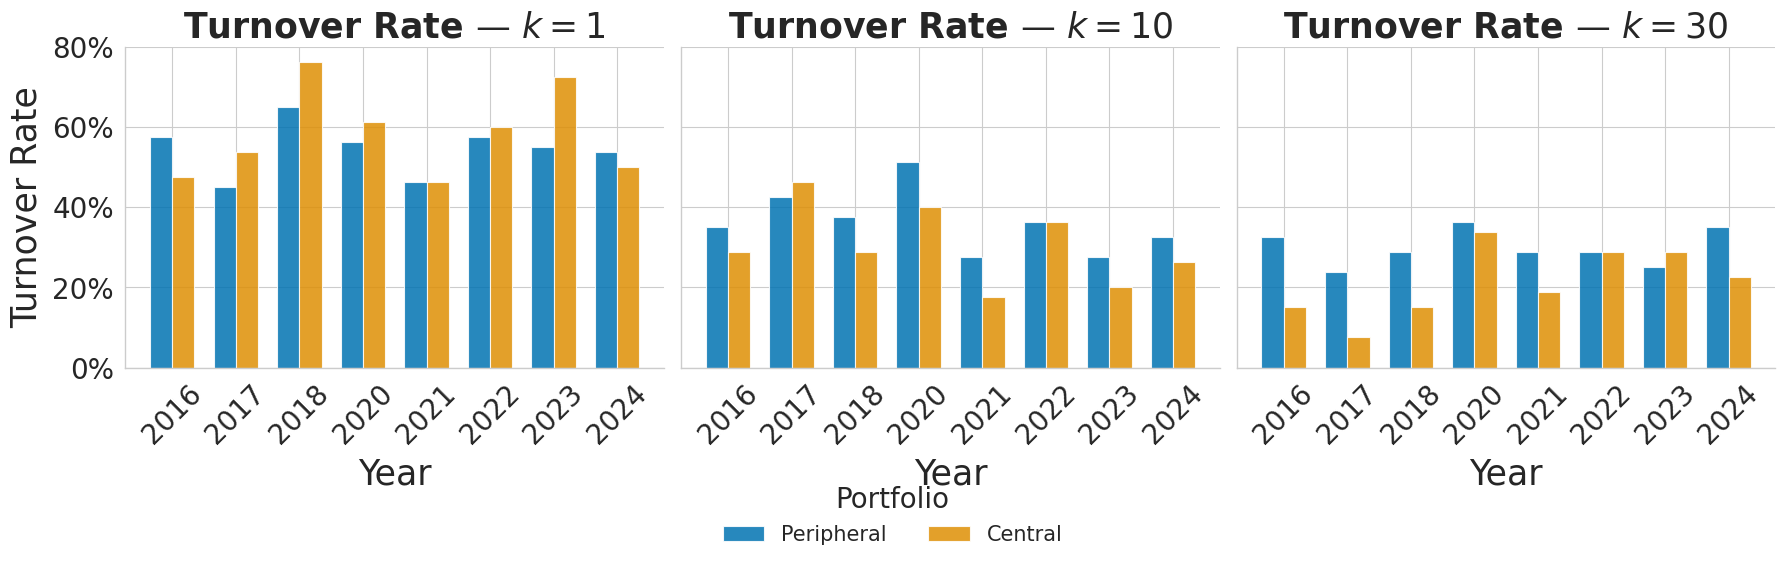

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, k in zip(axes, k_values):
    turnover_df = turnover_df_k[k]
    width = 0.35
    years = sorted(turnover_df["year"].unique())
    x = range(len(years))
    offsets = [-width / 2, width / 2]

    for i, portfolio in enumerate(["peripheral", "central"]):
        group = turnover_df[turnover_df["portfolio"] == portfolio].sort_values("year")
        ax.bar(
            [xi + offsets[i] for xi in x], group["turnover_rate"],
            width=width, color=palette[i], alpha=0.85,
            label=f"{portfolio.capitalize()}"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45, fontsize=15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
    ax.set_title(f"Turnover Rate — $k={k}$", fontsize=25, fontweight="bold", pad=7)
    ax.set_xlabel("Year", fontsize=25, labelpad=6)
    ax.tick_params(axis="both", labelsize=20)

# Set Y-label only on the first subplot since they share Y
axes[0].set_ylabel("Turnover Rate", fontsize=25, labelpad=6)

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=2, title="Portfolio", title_fontsize=20, fontsize=15, frameon=False)

sns.despine(fig=fig)
plt.tight_layout()

# Adjust layout to make room for the legend at the bottom if needed
plt.subplots_adjust(bottom=0.25) 

plt.savefig("../../figures/turnover_evolution.png", dpi=300, bbox_inches="tight")
plt.show()